In [4]:
#주피터노트북2 저장 가장 기본형태가 이거 나머지는 다 변형된거임(드롭아웃씀)
#1.환경설정 및 라이브러리 로드
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import csv

# GPU 디바이스 확인,GPU를 사용할 수 있는지 확인하고, 사용 가능한 디바이스를 설정합니다
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

# 경로 설정
base_dir = "C:/Users/user/OneDrive/Desktop/Camter_IAI/tent-classification/data/camter_tent_data"

# 데이터 증강 및 전처리
transform = transforms.Compose([
    transforms.RandomResizedCrop(224),  # 이미지를 224x224로 자르고, 랜덤 크기 조정
    transforms.RandomHorizontalFlip(),  # 이미지 좌우 뒤집기,이미지가 50% 확률로 좌우 반전됩니다.
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 밝기, 대비, 채도, 색조 변화., brightness=0.2: 이미지 밝기를 원래 밝기의 ±20% 범위 내에서 무작위로 조정.
    transforms.ToTensor(),  # 이미지를 PyTorch 텐서로 변환합니다.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # 정규화 , [0.485, 0.456, 0.406]은 ImageNet 데이터셋에서 사전 학습된 모델(EfficientNet 등)에서 사용된 평균값입니다.
])

# 데이터셋 로드 및 분할,dataset은 각 샘플이 (이미지, 레이블(0,1)) 쌍으로 구성된 PyTorch 데이터셋 객체입니다.
dataset = datasets.ImageFolder(root=base_dir, transform=transform)#데이터를 ImageFolder로 불러옴,디렉토리 구조를 기반으로 이미지를 로드하고, 해당 이미지의 레이블을 자동으로 할당합니다.
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])#데이터를 로드 후 학습데이터와 검증데이터로 나눔눔 8:2,random_split은 데이터를 무작위로 학습용과 검증용으로 나눕니다.

# 데이터 로더 설정,DataLoader를 사용하여 배치 단위로 데이터를 로드합니다
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
#guswo loader는 (이미지,레이블) 쌍으로 구성됨됨

# EfficientNetB0 모델 로드
from torchvision.models import EfficientNet_B0_Weights

#EfficientNet-B0 모델을 로드하고
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)#사전 학습된 가중치(IMAGENET1K_V1)를 사용.
num_classes = len(dataset.classes)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),#드롭아웃시 사용
    nn.Linear(model.classifier[1].in_features, num_classes)#기존 입력크기,새로운 클래스 개수로 마지막 레이어를 새로운 선형 레이어로 교체체
)
model = model.to(device)#모델을 디바이스로 이동

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()#손실함수 정의,예측결과와 실제 레이블간의 차이를 계산, 1.모델 출력 로짓(logit)을 Softmax로 변환하여 확률 분포 생성 2.실제 레이블과의 교차 엔트로피 손실을 계산.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#옵티마이저 adam, 학습률 0.001

# ====== 학습 및 검증 ======
EPOCHS = 300
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    # ===== 학습 =====
    model.train() #모델을 학습 모드로 전환.
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) #데이터를 모델과 동일한 디바이스(GPU/CPU)로 이동.

        optimizer.zero_grad()
        outputs = model(images)#모델에 이미지를 입력하여 예측 결과(outputs)를 생성. 클래스 확률 리스트 반환환
        loss = criterion(outputs, labels)#교차 엔트로피 손실실
        loss.backward()#역전파로 기울기 계산
        optimizer.step()#옵티마이저가 기울기를 사용해 모델의 파라미터를 업데이트.

        # 손실값 누적
        running_loss += loss.item()

        # 학습 정확도 계산
        _, predicted = torch.max(outputs, 1)#예측 결과(outputs)에서 클래스 확률이 가장 높은 인덱스를 가져옵니다.
        correct_train += (predicted == labels).sum().item()#예측이 실제 레이블과 일치하는 샘플수를 누적
        total_train += labels.size(0)#전체 샘플수 누적

    train_accuracy = correct_train / total_train
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # ===== 검증 =====
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)#모델에 입력 이미지(images)를 전달하여 예측 결과(outputs)를 생성.

            # 손실값 누적
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # 검증 정확도 계산
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    val_accuracy = correct_val / total_val
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_accuracy)

    # ===== 결과 출력 =====
    print((
        f"에폭 [{epoch + 1}/{EPOCHS}] - "
        f"학습 손실값: {running_loss/len(train_loader):.4f} - "
        f"학습 정확도: {train_accuracy:.4f} - "
        f"검증 손실값: {val_loss/len(val_loader):.4f} - "
        f"검증 정확도: {val_accuracy:.4f}"
    ))

# # ====== 학습 결과 저장 경로 설정 ======
# csv_dir = "C:/Users/user/OneDrive/Desktop/Camter_IAI/tent-classification/csv"
# os.makedirs(csv_dir, exist_ok=True)  # 폴더가 없으면 생성

# csv_path = os.path.join(csv_dir, "training_results.csv")

# # ====== 학습 과정 CSV로 저장 ======
# with open(csv_path, mode='w', newline='', encoding='utf-8-sig') as file:
#     writer = csv.writer(file)

#     # 헤더 작성
#     writer.writerow(["Epoch", "Train Loss", "Valid Loss", "Train Accuracy", "Valid Accuracy"])

#     # 에폭별 데이터 작성
#     for epoch in range(EPOCHS):
#         writer.writerow([
#             epoch + 1,  # 에폭
#             train_losses[epoch],  # 학습 손실값
#             val_losses[epoch],  # 검증 손실값
#             train_accuracies[epoch],  # 학습 정확도
#             val_accuracies[epoch]  # 검증 정확도
#         ])

# print(f"학습 과정이 '{csv_path}'에 저장되었습니다.")

#====== 모델 저장 경로 설정 ======
model_dir = "C:/Users/user/OneDrive/Desktop/Camter_IAI/tent-classification/models"
os.makedirs(model_dir, exist_ok=True)  # 폴더가 없으면 생성

model_path = os.path.join(model_dir, "efficientnet_tent_model.pth")

# ====== 모델 저장 ======
torch.save(model.state_dict(), model_path)
print(f"모델 가중치가 '{model_path}'에 저장되었습니다.")

사용 중인 디바이스: cuda
에폭 [1/300] - 학습 손실값: 2.0734 - 학습 정확도: 0.2822 - 검증 손실값: 1.7775 - 검증 정확도: 0.3636
에폭 [2/300] - 학습 손실값: 1.4582 - 학습 정확도: 0.5008 - 검증 손실값: 1.4857 - 검증 정확도: 0.4606
에폭 [3/300] - 학습 손실값: 1.1249 - 학습 정확도: 0.5873 - 검증 손실값: 1.3715 - 검증 정확도: 0.4909
에폭 [4/300] - 학습 손실값: 1.1287 - 학습 정확도: 0.6039 - 검증 손실값: 1.2955 - 검증 정확도: 0.5576
에폭 [5/300] - 학습 손실값: 0.8831 - 학습 정확도: 0.6525 - 검증 손실값: 1.2541 - 검증 정확도: 0.5576
에폭 [6/300] - 학습 손실값: 0.8241 - 학습 정확도: 0.6844 - 검증 손실값: 1.6191 - 검증 정확도: 0.4606
에폭 [7/300] - 학습 손실값: 0.8640 - 학습 정확도: 0.6980 - 검증 손실값: 1.2514 - 검증 정확도: 0.5636
에폭 [8/300] - 학습 손실값: 0.8538 - 학습 정확도: 0.6950 - 검증 손실값: 1.1129 - 검증 정확도: 0.5939
에폭 [9/300] - 학습 손실값: 0.8804 - 학습 정확도: 0.6586 - 검증 손실값: 1.3008 - 검증 정확도: 0.5636
에폭 [10/300] - 학습 손실값: 0.7308 - 학습 정확도: 0.7102 - 검증 손실값: 1.1604 - 검증 정확도: 0.6182
에폭 [11/300] - 학습 손실값: 0.7164 - 학습 정확도: 0.7344 - 검증 손실값: 1.3097 - 검증 정확도: 0.6121
에폭 [12/300] - 학습 손실값: 0.6580 - 학습 정확도: 0.7527 - 검증 손실값: 1.3933 - 검증 정확도: 0.5818
에폭 [13/300] - 학습 손실값: 0.6717 - 학

In [3]:
#주피터노트북2 저장 가장 기본형태가 이거 나머지는 다 변형된거임
#1.환경설정 및 라이브러리 로드
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import csv

# GPU 디바이스 확인,GPU를 사용할 수 있는지 확인하고, 사용 가능한 디바이스를 설정합니다
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

# 경로 설정
base_dir = "C:/Users/user/OneDrive/Desktop/Camter_IAI/tent-classification/data/camter_tent_data2"

# 데이터 증강 및 전처리
transform = transforms.Compose([
    transforms.RandomResizedCrop(224),  # 이미지를 224x224로 자르고, 랜덤 크기 조정
    transforms.RandomHorizontalFlip(),  # 이미지 좌우 뒤집기,이미지가 50% 확률로 좌우 반전됩니다.
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 밝기, 대비, 채도, 색조 변화., brightness=0.2: 이미지 밝기를 원래 밝기의 ±20% 범위 내에서 무작위로 조정.
    transforms.ToTensor(),  # 이미지를 PyTorch 텐서로 변환합니다.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # 정규화 , [0.485, 0.456, 0.406]은 ImageNet 데이터셋에서 사전 학습된 모델(EfficientNet 등)에서 사용된 평균값입니다.
])

# 데이터셋 로드 및 분할,dataset은 각 샘플이 (이미지, 레이블(0,1)) 쌍으로 구성된 PyTorch 데이터셋 객체입니다.
dataset = datasets.ImageFolder(root=base_dir, transform=transform)#데이터를 ImageFolder로 불러옴,디렉토리 구조를 기반으로 이미지를 로드하고, 해당 이미지의 레이블을 자동으로 할당합니다.
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])#데이터를 로드 후 학습데이터와 검증데이터로 나눔눔 8:2,random_split은 데이터를 무작위로 학습용과 검증용으로 나눕니다.

# 데이터 로더 설정,DataLoader를 사용하여 배치 단위로 데이터를 로드합니다
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
#guswo loader는 (이미지,레이블) 쌍으로 구성됨됨

# EfficientNetB0 모델 로드
from torchvision.models import EfficientNet_B0_Weights

#EfficientNet-B0 모델을 로드하고
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)#사전 학습된 가중치(IMAGENET1K_V1)를 사용.
num_classes = len(dataset.classes)
model.classifier = nn.Sequential(
    #nn.Dropout(p=0.2),#드롭아웃시 사용
    nn.Linear(model.classifier[1].in_features, num_classes)#기존 입력크기,새로운 클래스 개수로 마지막 레이어를 새로운 선형 레이어로 교체체
)
model = model.to(device)#모델을 디바이스로 이동

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()#손실함수 정의,예측결과와 실제 레이블간의 차이를 계산, 1.모델 출력 로짓(logit)을 Softmax로 변환하여 확률 분포 생성 2.실제 레이블과의 교차 엔트로피 손실을 계산.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#옵티마이저 adam, 학습률 0.001

# ====== 학습 및 검증 ======
EPOCHS = 100
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    # ===== 학습 =====
    model.train() #모델을 학습 모드로 전환.
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) #데이터를 모델과 동일한 디바이스(GPU/CPU)로 이동.

        optimizer.zero_grad()
        outputs = model(images)#모델에 이미지를 입력하여 예측 결과(outputs)를 생성. 클래스 확률 리스트 반환환
        loss = criterion(outputs, labels)#교차 엔트로피 손실실
        loss.backward()#역전파로 기울기 계산
        optimizer.step()#옵티마이저가 기울기를 사용해 모델의 파라미터를 업데이트.

        # 손실값 누적
        running_loss += loss.item()

        # 학습 정확도 계산
        _, predicted = torch.max(outputs, 1)#예측 결과(outputs)에서 클래스 확률이 가장 높은 인덱스를 가져옵니다.
        correct_train += (predicted == labels).sum().item()#예측이 실제 레이블과 일치하는 샘플수를 누적
        total_train += labels.size(0)#전체 샘플수 누적

    train_accuracy = correct_train / total_train
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # ===== 검증 =====
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)#모델에 입력 이미지(images)를 전달하여 예측 결과(outputs)를 생성.

            # 손실값 누적
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # 검증 정확도 계산
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    val_accuracy = correct_val / total_val
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_accuracy)

    # ===== 결과 출력 =====
    print((
        f"에폭 [{epoch + 1}/{EPOCHS}] - "
        f"학습 손실값: {running_loss/len(train_loader):.4f} - "
        f"학습 정확도: {train_accuracy:.4f} - "
        f"검증 손실값: {val_loss/len(val_loader):.4f} - "
        f"검증 정확도: {val_accuracy:.4f}"
    ))

# # ====== 학습 결과 저장 경로 설정 ======
# csv_dir = "C:/Users/user/OneDrive/Desktop/Camter_IAI/tent-classification/csv"
# os.makedirs(csv_dir, exist_ok=True)  # 폴더가 없으면 생성

# csv_path = os.path.join(csv_dir, "training_results.csv")

# # ====== 학습 과정 CSV로 저장 ======
# with open(csv_path, mode='w', newline='', encoding='utf-8-sig') as file:
#     writer = csv.writer(file)

#     # 헤더 작성
#     writer.writerow(["Epoch", "Train Loss", "Valid Loss", "Train Accuracy", "Valid Accuracy"])

#     # 에폭별 데이터 작성
#     for epoch in range(EPOCHS):
#         writer.writerow([
#             epoch + 1,  # 에폭
#             train_losses[epoch],  # 학습 손실값
#             val_losses[epoch],  # 검증 손실값
#             train_accuracies[epoch],  # 학습 정확도
#             val_accuracies[epoch]  # 검증 정확도
#         ])

# print(f"학습 과정이 '{csv_path}'에 저장되었습니다.")

#====== 모델 저장 경로 설정 ======
model_dir = "C:/Users/user/OneDrive/Desktop/Camter_IAI/tent-classification/models"
os.makedirs(model_dir, exist_ok=True)  # 폴더가 없으면 생성

model_path = os.path.join(model_dir, "efficientnet_tent_model2.pth")

# ====== 모델 저장 ======
torch.save(model.state_dict(), model_path)
print(f"모델 가중치가 '{model_path}'에 저장되었습니다.")

사용 중인 디바이스: cuda
에폭 [1/100] - 학습 손실값: 1.5430 - 학습 정확도: 0.3808 - 검증 손실값: 1.4007 - 검증 정확도: 0.5361
에폭 [2/100] - 학습 손실값: 1.0339 - 학습 정확도: 0.6192 - 검증 손실값: 0.9275 - 검증 정확도: 0.6907
에폭 [3/100] - 학습 손실값: 0.7139 - 학습 정확도: 0.7539 - 검증 손실값: 0.6131 - 검증 정확도: 0.7113
에폭 [4/100] - 학습 손실값: 0.7777 - 학습 정확도: 0.7824 - 검증 손실값: 0.7997 - 검증 정확도: 0.7010
에폭 [5/100] - 학습 손실값: 0.6039 - 학습 정확도: 0.7979 - 검증 손실값: 0.7052 - 검증 정확도: 0.6701
에폭 [6/100] - 학습 손실값: 0.5878 - 학습 정확도: 0.7772 - 검증 손실값: 0.6465 - 검증 정확도: 0.7320
에폭 [7/100] - 학습 손실값: 0.4995 - 학습 정확도: 0.8187 - 검증 손실값: 0.7091 - 검증 정확도: 0.7216
에폭 [8/100] - 학습 손실값: 0.5824 - 학습 정확도: 0.8057 - 검증 손실값: 0.8952 - 검증 정확도: 0.7010
에폭 [9/100] - 학습 손실값: 0.7875 - 학습 정확도: 0.7798 - 검증 손실값: 0.9847 - 검증 정확도: 0.6598
에폭 [10/100] - 학습 손실값: 0.5756 - 학습 정확도: 0.8264 - 검증 손실값: 0.9036 - 검증 정확도: 0.5979
에폭 [11/100] - 학습 손실값: 0.5490 - 학습 정확도: 0.8135 - 검증 손실값: 0.6958 - 검증 정확도: 0.7423
에폭 [12/100] - 학습 손실값: 0.6293 - 학습 정확도: 0.8316 - 검증 손실값: 0.7343 - 검증 정확도: 0.7113
에폭 [13/100] - 학습 손실값: 0.8150 - 학

C:\Users\user\AppData\Local\Temp\ipykernel_1780\4245216000.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

테스트 이미지 경로: C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\data\camter_tent_data\0 헬리녹스 알파인돔\A23.jpg
실제 텐트: 0 헬리녹스 알파인돔
예측된 텐트: 1 헬리녹스 노나돔


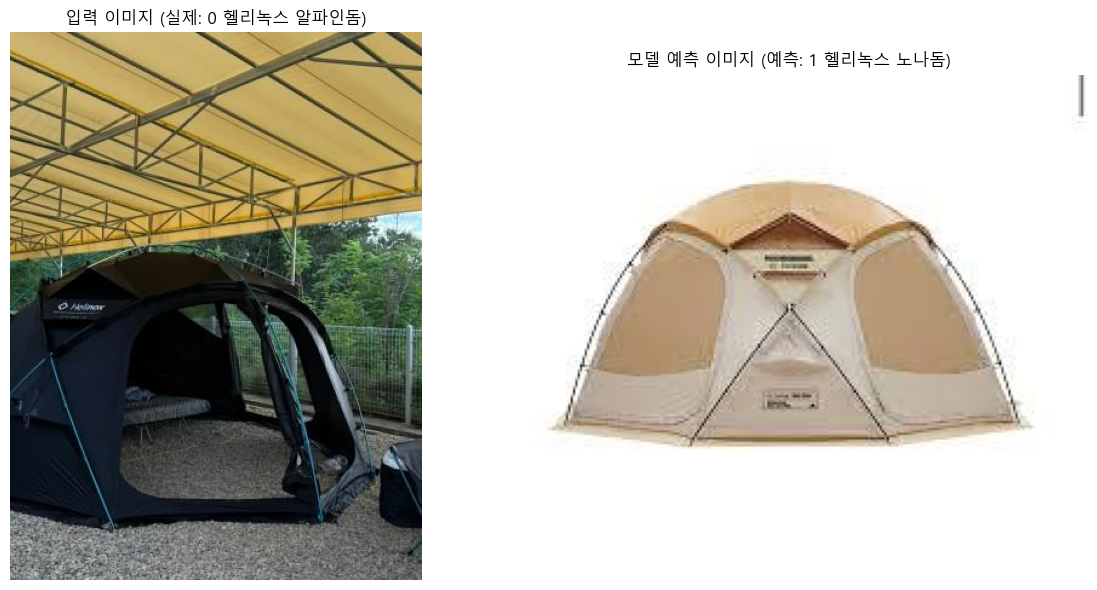

예측된 디렉토리 경로: C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\data\camter_tent_data\1 헬리녹스 노나돔
디렉토리 존재 여부: True
예측된 디렉토리 내부 파일: ['B1.jpg', 'B10.jpg', 'B100.jpg', 'B101.jpg', 'B103.jpg', 'B104.jpg', 'B105.jpg', 'B106.jpg', 'B107.jpg', 'B108.jpg', 'B109.jpg', 'B11.jpg', 'B110.jpg', 'B111.jpg', 'B112.jpg', 'B113.jpg', 'B114.jpg', 'B115.jpg', 'B116.jpg', 'B117.jpg', 'B118.jpg', 'B119.jpg', 'B120.jpg', 'B121.jpg', 'B122.jpg', 'B123.jpg', 'B124.jpg', 'B125.jpg', 'B126.jpg', 'B127.jpg', 'B128.jpg', 'B129.jpg', 'B13.jpg', 'B131.jpg', 'B132.jpg', 'B133.jpg', 'B134.jpg', 'B135.jpg', 'B136.jpg', 'B137.jpg', 'B138.jpg', 'B139.jpg', 'B14.jpg', 'B140.jpg', 'B141.jpg', 'B142.jpg', 'B143.jpg', 'B144.jpg', 'B145.jpg', 'B15.jpg', 'B16.jpg', 'B17.jpg', 'B18.jpg', 'B19.jpg', 'B2.jpg', 'B20.jpg', 'B21.jpg', 'B22.jpg', 'B23.jpg', 'B24.jpg', 'B25.jpg', 'B26.jpg', 'B27.jpg', 'B28.jpg', 'B29.jpg', 'B3.jpg', 'B30.jpg', 'B31.jpg', 'B32.jpg', 'B33.jpg', 'B34.jpg', 'B35.jpg', 'B36.jpg', 'B37.jpg', 'B3

In [6]:
#직접 이미지를 넣어 텐트명을 예측하는 코드
import os
import difflib
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import rc
import platform
import matplotlib

# 한글 폰트 설정
if platform.system() == "Windows":
    rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    rc("font", family="AppleGothic")
else:
    rc("font", family="NanumGothic")
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== 경로 설정 =====
test_image_path = r"C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\data\camter_tent_data\0 헬리녹스 알파인돔\A23.jpg"
model_path = r"C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\models\efficientnet_tent_model.pth"
base_dir = r"C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\data\camter_tent_data"
class_names = [
    "0 헬리녹스 알파인돔", 
    "1 헬리녹스 노나돔", 
    "2 헬리녹스 브이타프",
    "3 스노우피크 도크돔",
    "4 스노우피크 랜드브리즈Pro.4",
    "5 스노우피크 랜드브리즈Pro.3",
    "6 스노우피크 어메니티돔M",
    "7 스노우피크 어매니티돔S",
    "8 코오롱스포츠 에어로라이트",
    "9 힐레베르그 알락",
    "10 헬스포츠 김레패밀리"
]

# 실제 정답 추출
actual_label = os.path.basename(os.path.dirname(test_image_path))

# ===== 모델 로드 =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(weights=None)
num_classes = len(class_names)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# ===== 이미지 전처리 =====
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image = Image.open(test_image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

# ===== 예측 수행 =====
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    top_prob, predicted_class = torch.max(probabilities, 1)
    predicted_label = class_names[predicted_class.item()]

# ===== 결과 출력 =====
print(f"테스트 이미지 경로: {test_image_path}")
print(f"실제 텐트: {actual_label}")
print(f"예측된 텐트: {predicted_label}")

# ===== 시각화 =====
plt.figure(figsize=(12, 6))

# 입력 이미지 시각화
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"입력 이미지 (실제: {actual_label})")
plt.axis("off")

# 모델이 예측한 텐트 이미지 시각화
predicted_dir = os.path.join(base_dir,predicted_label)
if os.path.exists(predicted_dir):
    predicted_images = os.listdir(predicted_dir)
    if predicted_images:
        predicted_image_path = os.path.join(predicted_dir, predicted_images[0])
        predicted_image = Image.open(predicted_image_path).convert("RGB")
        
        plt.subplot(1, 2, 2)
        plt.imshow(predicted_image)
        plt.title(f"모델 예측 이미지 (예측: {predicted_label})")
        plt.axis("off")
    else:
        print(f"예측된 클래스의 이미지 파일이 없습니다: {predicted_dir}")
else:
    print(f"예측된 클래스 디렉토리가 없습니다: {predicted_dir}")

plt.tight_layout()
plt.show()
print(f"예측된 디렉토리 경로: {predicted_dir}")
print(f"디렉토리 존재 여부: {os.path.exists(predicted_dir)}")
print(f"예측된 디렉토리 내부 파일: {predicted_images}")



c:\Users\user\anaconda3\envs\myenv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\anaconda3\envs\myenv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\user\AppData\Local\Temp\ipykernel_1780\1469495402.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_o

테스트 이미지 경로: C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\data\camter_tent_data2\0 헬리녹스 알파인돔\A3.jpg
실제 텐트: 0 헬리녹스 알파인돔
예측된 텐트: 0 헬리녹스 알파인돔


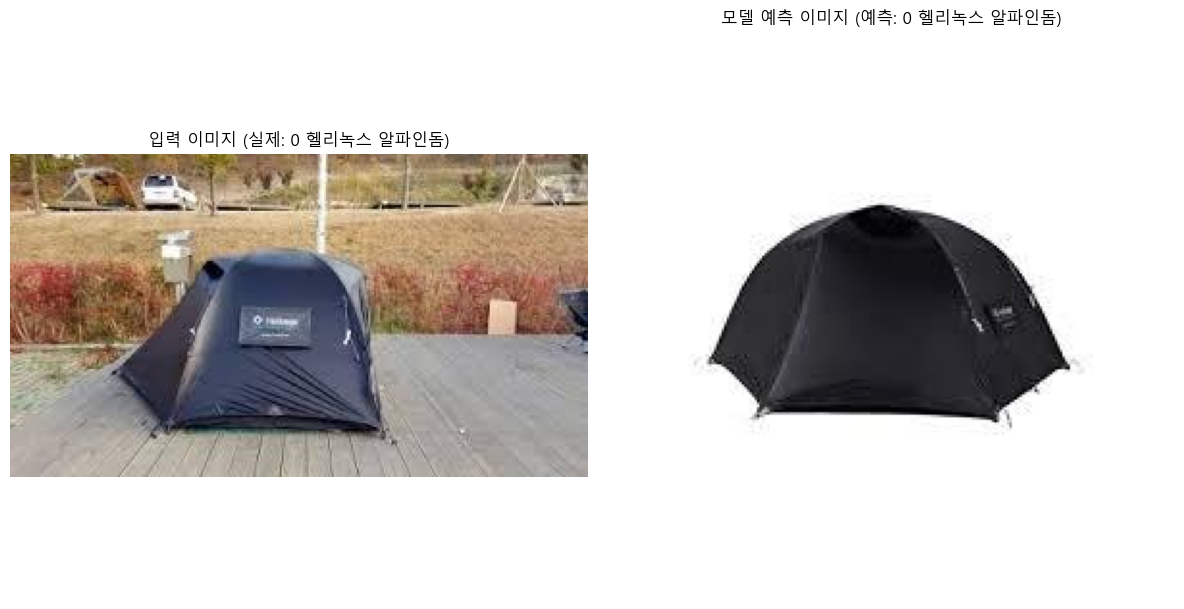

예측된 디렉토리 경로: C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\data\camter_tent_data2\0 헬리녹스 알파인돔
디렉토리 존재 여부: True
예측된 디렉토리 내부 파일: ['A1.jpg', 'A10.jpg', 'A102.jpg', 'A103.jpg', 'A108.jpg', 'A11.jpg', 'A112.jpg', 'A113.jpg', 'A115.jpg', 'A120.jpg', 'A126.jpg', 'A127.jpg', 'A129.jpg', 'A131.jpg', 'A17.jpg', 'A18.jpg', 'A19.jpg', 'A20.jpg', 'A22.jpg', 'A23.jpg', 'A26.jpg', 'A27.jpg', 'A28.jpg', 'A29.jpg', 'A3.jpg', 'A30.jpg', 'A31.jpg', 'A32.jpg', 'A34.jpg', 'A37.jpg', 'A38.jpg', 'A4.jpg', 'A42.jpg', 'A43.jpg', 'A45.jpg', 'A46.jpg', 'A48.jpg', 'A50.jpg', 'A55.jpg', 'A59.jpg', 'A63.jpg', 'A68.jpg', 'A7.jpg', 'A70.jpg', 'A71.jpg', 'A72.jpg', 'A73.jpg', 'A74.jpg', 'A75.jpg', 'A76.jpg', 'A77.jpg', 'A78.jpg', 'A8.jpg', 'A84.jpg', 'A87.jpg', 'A88.jpg', 'A9.jpg', 'A92.jpg', 'A94.jpg', 'A98.jpg']


In [7]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import rc
import platform
import matplotlib

# 한글 폰트 설정
if platform.system() == "Windows":
    rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":
    rc("font", family="AppleGothic")
else:
    rc("font", family="NanumGothic")
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== 경로 설정 =====
test_image_path = r"C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\data\camter_tent_data2\0 헬리녹스 알파인돔\A3.jpg"
model_path = r"C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\models\efficientnet_tent_model2.pth"
base_dir = r"C:\Users\user\OneDrive\Desktop\Camter_IAI\tent-classification\data\camter_tent_data2"
class_names = [
    "0 헬리녹스 알파인돔", 
    "1 헬리녹스 노나돔", 
    "2 헬리녹스 브이타프",
    "3 스노우피크 도크돔",
    "9 힐레베르그 알락",
    "10 헬스포츠 김레패밀리"
]

# 실제 정답 추출
actual_label = os.path.basename(os.path.dirname(test_image_path))

# ===== 모델 로드 =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(pretrained=False)
num_classes = len(class_names)

# 저장된 모델 구조에 맞게 classifier 정의
model.classifier = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# ===== 이미지 전처리 =====
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 테스트 이미지 로드
try:
    image = Image.open(test_image_path).convert("RGB")
except FileNotFoundError:
    print(f"테스트 이미지 파일을 찾을 수 없습니다: {test_image_path}")
    exit()

input_tensor = transform(image).unsqueeze(0).to(device)

# ===== 예측 수행 =====
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    top_prob, predicted_class = torch.max(probabilities, 1)
    predicted_label = class_names[predicted_class.item()]

# ===== 결과 출력 =====
print(f"테스트 이미지 경로: {test_image_path}")
print(f"실제 텐트: {actual_label}")
print(f"예측된 텐트: {predicted_label}")

# ===== 시각화 =====
plt.figure(figsize=(12, 6))

# 입력 이미지 시각화
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"입력 이미지 (실제: {actual_label})")
plt.axis("off")

# 모델이 예측한 텐트 이미지 시각화
predicted_dir = os.path.join(base_dir, predicted_label)
if os.path.exists(predicted_dir):
    predicted_images = os.listdir(predicted_dir)
    if predicted_images:
        predicted_image_path = os.path.join(predicted_dir, predicted_images[0])
        try:
            predicted_image = Image.open(predicted_image_path).convert("RGB")
            plt.subplot(1, 2, 2)
            plt.imshow(predicted_image)
            plt.title(f"모델 예측 이미지 (예측: {predicted_label})")
            plt.axis("off")
        except FileNotFoundError:
            print(f"예측된 클래스의 이미지 파일을 로드할 수 없습니다: {predicted_image_path}")
    else:
        print(f"예측된 클래스의 이미지 파일이 없습니다: {predicted_dir}")
else:
    print(f"예측된 클래스 디렉토리가 없습니다: {predicted_dir}")

plt.tight_layout()
plt.show()

print(f"예측된 디렉토리 경로: {predicted_dir}")
print(f"디렉토리 존재 여부: {os.path.exists(predicted_dir)}")
if os.path.exists(predicted_dir):
    print(f"예측된 디렉토리 내부 파일: {os.listdir(predicted_dir)}")
